# PoC: Feature Extraction and Validation

This notebook serves as a workspace to validate our PyTorch implementation of the feature extraction pipeline against the original `DCASE-models` reference.

**Goals:**
1. Load an audio file from the URBAN-SED dataset.
2. Extract MelSpectrogram features using our new `MelSpectogramExtractor`.
3. Extract features from the same file using the original `dcase_models` library.
4. Visually and numerically compare the outputs to ensure parity.

# Acacias Sound Monitoring
## Descripción del proyecto
El proyecto "Acacias Sound Monitoring" tiene como objetivo implementar un sistema de monitoreo de sonido en la ciudad de Acacias. Este sistema permitirá detectar y analizar los niveles de ruido y las fuentes de sonido en diferentes áreas de la ciudad, con el fin de mejorar la calidad de vida de los habitantes y promover un ambiente más saludable.

## Referencias
1. [SONYC](https://wp.nyu.edu/sonyc/)
2. [Pamplona Monitoring](https://www.upf.edu/web/mtg/news/-/asset_publisher/WM181VyAQipW/content/acousticsensorspamplona/maximized)
3. [MOSMO](https://iie.fing.edu.uy/proyectos/mosmo/)
4. [DCASE Models](https://github.com/MTG/DCASE-models)
5. [Urban Sound Classification](https://urbansounddataset.weebly.com/)


### 1. Imports and Setup

First, we import all necessary libraries and add our `src` directory to the path to import our custom modules. We also set up paths to both our new project and the original `DCASE-models` project.

In [2]:
import torch
import torchaudio
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import sys
from IPython.display import Audio, display

# --- Add project source directories to Python path ---

# Add our new project's src folder
sys.path.append('../src')

# IMPORTANT: Add the path to the original DCASE-models repository
# This is necessary to import its feature extractor for comparison.
# Please adjust the path if it's located elsewhere.
DCASE_MODELS_PATH = '../../DCASE-models'
sys.path.append(DCASE_MODELS_PATH)

# --- Import our custom and the original modules ---

# Our new PyTorch-based extractor
from sbcnn_sed.data.features import MelSpectrogramExtractor

# The original librosa-based extractor
from dcase_models.data.features import MelSpectrogram as LibrosaMelSpectrogram

print("Imports successful.")

# --- Configuration ---
# Use a specific audio file from the dataset for consistent testing.
# This file is from the URBAN-SED training set.
AUDIO_FILE = '../data/raw/URBAN-SED_v2.0.0/audio/train/soundscape_train_unimodal1.wav'
print(f"Audio file for testing: {AUDIO_FILE}")

Imports successful.
Audio file for testing: ../data/raw/URBAN-SED_v2.0.0/audio/train/soundscape_train_unimodal1.wav


### 2. Load and Listen to the Audio Sample

Let's load the selected audio file and listen to it to get a sense of the data we're working with.

In [3]:
# Load the audio file for playback
waveform, sr = torchaudio.load(AUDIO_FILE)

print(f"Audio loaded. Sample rate: {sr}, Duration: {waveform.shape[1]/sr:.2f}s")

# Create an interactive audio player in the notebook
display(Audio(data=waveform, rate=sr))

Audio loaded. Sample rate: 44100, Duration: 10.00s


### 3. Feature Extraction with Our PyTorch Implementation

Now, we'll use our new `MelSpectogramExtractor` to process the audio file.

/home/julia/juli/projects/marso/acacias-sound-monitor/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch feature sequences shape: torch.Size([20, 32, 64])


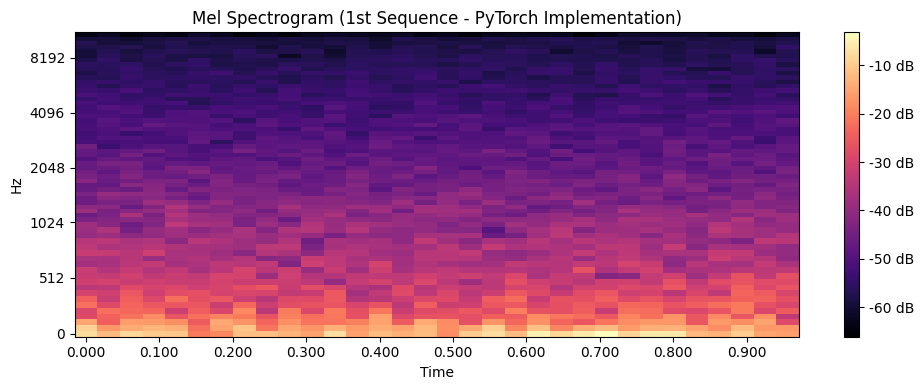

In [4]:
# Initialize our extractor with the reference parameters
pytorch_extractor = MelSpectrogramExtractor(
    sample_rate=22050,
    n_fft=1024,
    win_length=1024,
    hop_length=680,
    n_mels=64,
    sequence_time=1.0,
    sequence_hop_time=0.5
)

pytorch_sequences = pytorch_extractor.extract(AUDIO_FILE)

pytorch_sequences = pytorch_sequences.to(torch.float64)

print(f"PyTorch feature sequences shape: {pytorch_sequences.shape}")

# Let's visualize the first sequence
if pytorch_sequences.shape[0] > 0:
    first_sequence_pt = pytorch_sequences[0]

    vmin = first_sequence_pt.min()
    vmax = first_sequence_pt.max()
    
    fig, ax = plt.subplots(figsize=(10, 4))
    img = librosa.display.specshow(first_sequence_pt.T.numpy(), 
                                   sr=pytorch_extractor.sample_rate, 
                                   hop_length=pytorch_extractor.hop_length, 
                                   x_axis='time', 
                                   y_axis='mel', 
                                   ax=ax,
                                   cmap='magma',
                                   vmin=vmin, vmax=vmax)
    
    fig.colorbar(img, ax=ax, format='%+2.0f dB')
    ax.set_title('Mel Spectrogram (1st Sequence - PyTorch Implementation)')
    plt.tight_layout()
    plt.show()
else:
    print("No sequences were generated. The audio file might be too short.")

### 4. Feature Extraction with the Original `DCASE-models` (Librosa)

This is the critical comparison step. We'll instantiate the original `MelSpectrogram` extractor from the `DCASE-models` library and run it on the same audio file. This gives us the "ground truth" that we need to match.

Changing sampling rate from 44100 to 22050
Librosa feature sequences shape: (20, 32, 64)


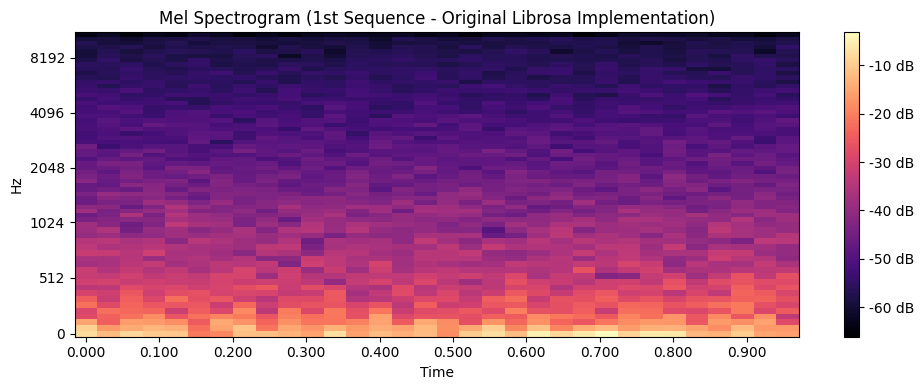

In [5]:
# Initialize the original librosa-based extractor with the same parameters
# Note: The original class has a different name, so we imported it as LibrosaMelSpectrogram
librosa_extractor = LibrosaMelSpectrogram(
    sequence_time=1.0,
    sequence_hop_time=0.5,
    audio_win=1024,
    audio_hop=680,
    sr=22050,
    n_fft=1024,
    mel_bands=64,
)

# The original extractor returns a numpy array
librosa_sequences = librosa_extractor.calculate(AUDIO_FILE)

print(f"Librosa feature sequences shape: {librosa_sequences.shape}")

# Visualize the first sequence from the original implementation
if librosa_sequences.shape[0] > 0:
    first_sequence_lb = librosa_sequences[0]
    
    fig, ax = plt.subplots(figsize=(10, 4))
    # The original output is already (time, mels), so no transpose needed for specshow's default
    img = librosa.display.specshow(first_sequence_lb.T, 
                                   sr=librosa_extractor.sr, 
                                   hop_length=librosa_extractor.audio_hop, 
                                   x_axis='time', 
                                   y_axis='mel', 
                                   ax=ax,
                                   cmap='magma',
                                   vmin=vmin, vmax=vmax)
    fig.colorbar(img, ax=ax, format='%+2.0f dB')
    ax.set_title('Mel Spectrogram (1st Sequence - Original Librosa Implementation)')
    plt.tight_layout()
    plt.show()
else:
    print("No sequences were generated by the librosa extractor.")

### 5. Parity Check: Comparing the Outputs

Now we compare the results. We'll check the shape, data type, and the numerical difference between the two outputs.

A small difference is acceptable due to floating-point arithmetic differences between libraries (`numpy` vs `torch`), but the values should be very close.

In [6]:
# Convert the librosa numpy array to a torch tensor for comparison
librosa_sequences_tensor = torch.from_numpy(librosa_sequences)

# 1. Check shapes
print(f"Shape - re-implementation: {pytorch_sequences.shape}")
print(f"Shape - original: {librosa_sequences_tensor.shape}")
if pytorch_sequences.shape == librosa_sequences_tensor.shape:
    print("✅ Shapes match!")
else:
    print("❌ Shapes DO NOT match!")

# 2. Check data types
print(f"\nDtype - Own: {pytorch_sequences.dtype}")
print(f"Dtype - Original: {librosa_sequences_tensor.dtype}")

# 3. Numerical difference
if pytorch_sequences.shape == librosa_sequences_tensor.shape:
    # Calculate the absolute difference
    diff = torch.abs(pytorch_sequences - librosa_sequences_tensor)
    
    print("\n--- Numerical Comparison ---")
    print(f"Max absolute difference:  {torch.max(diff).item():.6f}")
    print(f"Mean absolute difference: {torch.mean(diff).item():.6f}")
    
    # A very low difference (e.g., < 1e-5) is a good sign of parity.
    if torch.allclose(pytorch_sequences, librosa_sequences_tensor, atol=1e-5):
        print("✅ Outputs are numerically very close!")
    else:
        print("⚠️ Outputs have a noticeable numerical difference. Further investigation needed.")
else:
    print("\nCannot perform numerical comparison because shapes do not match.")

Shape - re-implementation: torch.Size([20, 32, 64])
Shape - original: torch.Size([20, 32, 64])
✅ Shapes match!

Dtype - Own: torch.float64
Dtype - Original: torch.float64

--- Numerical Comparison ---
Max absolute difference:  0.000004
Mean absolute difference: 0.000001
✅ Outputs are numerically very close!


/tmp/ipykernel_32052/178729440.py:2: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:206.)
  librosa_sequences_tensor = torch.from_numpy(librosa_sequences)
